# Seminar 08: Self-Attention from Scratch and the Bridge to Vision

**Student Version**

Goals for today:
- Build the full self-attention pipeline from tensors
- Debug common attention mistakes with shapes and row-sum checks
- Implement single-head self-attention as a PyTorch module
- Add causal masking and compare masked/unmasked attention maps
- Turn image patches into tokens and run attention over them


## 0. Setup

In [1]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cpu')

### Helpers

In [2]:
def print_shape(name, x):
    if x is None:
        print(f'{name}: not filled yet')
        return
    print(f'{name}: shape={tuple(x.shape)} dtype={x.dtype}')


def show_attention_heatmap(attn, title='Attention weights'):
    """attn: [T, T] or [1, T, T]"""
    if attn.ndim == 3:
        attn = attn[0]
    attn = attn.detach().cpu().numpy()
    plt.figure(figsize=(5, 4))
    plt.imshow(attn)
    plt.title(title)
    plt.xlabel('key position')
    plt.ylabel('query position')
    plt.colorbar()
    plt.show()


def check_row_sums(attn, atol=1e-6):
    row_sums = attn.sum(dim=-1)
    return torch.allclose(row_sums, torch.ones_like(row_sums), atol=atol)


def count_parameters(module):
    return sum(p.numel() for p in module.parameters())


## 1. Attention by Hand

We start with one tiny sequence of token embeddings.

Shape notation:
- `B` = batch size
- `T` = number of tokens
- `D` = embedding dimension
- `d_k` = query/key dimension
- `d_v` = value dimension

### Exercise 1
Create `X` with shape `[1, 4, 6]`. Then create three projection matrices and compute the full scaled dot-product attention pipeline.

Use:
- `d_k = 4`
- `d_v = 4`

Useful contracts:
- `X @ W_Q`: if `X` has shape `[B, T, D]`, then `W_Q` should map `D -> d_k`.
- `K.transpose(-2, -1)`: swaps the token and feature axes, so `[B, T, d_k]` becomes `[B, d_k, T]`.
- `torch.softmax(scores, dim=-1)`: applies softmax across keys for every query row.


X: shape=(1, 4, 6) dtype=torch.float32
scores: shape=(1, 4, 4) dtype=torch.float32
attn_weights: shape=(1, 4, 4) dtype=torch.float32
attn_output: shape=(1, 4, 4) dtype=torch.float32


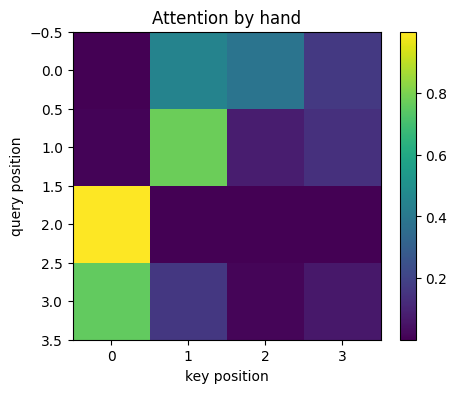

In [4]:
# Exercise 1

B = 1
T = 4
D = 6
d_k = 4
d_v = 4

X = torch.randn(B, T, D)

W_Q = torch.randn(D, d_k)
W_K = torch.randn(D, d_k)
W_V = torch.randn(D, d_v)

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

scores = Q @ K.transpose(-2, -1)
scaled_scores = scores / math.sqrt(d_k)
attn_weights = torch.softmax(scaled_scores, -1)
attn_output = attn_weights @ V

# Print the main shapes after you fill the variables.
print_shape('X', X)
print_shape('scores', scores)
print_shape('attn_weights', attn_weights)
print_shape('attn_output', attn_output)
show_attention_heatmap(attn_weights, title='Attention by hand')


### Checks (Exercise 1)


In [5]:
assert isinstance(X, torch.Tensor)
assert X.shape == (1, 4, 6)
assert W_Q.shape == (6, 4)
assert W_K.shape == (6, 4)
assert W_V.shape == (6, 4)
assert Q.shape == (1, 4, 4)
assert K.shape == (1, 4, 4)
assert V.shape == (1, 4, 4)
assert scores.shape == (1, 4, 4)
assert scaled_scores.shape == (1, 4, 4)
assert attn_weights.shape == (1, 4, 4)
assert attn_output.shape == (1, 4, 4)
assert torch.allclose(scores, Q @ K.transpose(-2, -1))
assert torch.allclose(scaled_scores, scores / math.sqrt(d_k))
assert check_row_sums(attn_weights)
assert torch.allclose(attn_output, attn_weights @ V)
print('Exercise 1 passed.')


Exercise 1 passed.


## 2. Scaling and Temperature Lab

With very small `d_k`, scaling may not look dramatic. The effect becomes clearer when the query/key dimension is larger, because unscaled dot products naturally become larger.

### Exercise 2
Create a separate attention example with `d_k_demo = 64`, then compare attention weights under different score transformations.

Part A: compare three choices:
- no scaling: `demo_scores`
- standard scaling: `demo_scores / sqrt(d_k_demo)`
- stronger scaling: `demo_scores / d_k_demo`

Part B: treat the denominator as a softmax temperature:
- low temperature makes attention sharper
- high temperature makes attention flatter

Useful contracts:
- `weights.max(dim=-1).values` gives the largest attention probability for each query token.
- Entropy can be computed as `-(weights * torch.log(weights + eps)).sum(dim=-1)`.
- Larger max probability means sharper attention; larger entropy means flatter attention.


Mean max probability
no scale      : tensor(0.9588)
sqrt(d_k_demo): tensor(0.5070)
d_k_demo      : tensor(0.2797)

Mean entropy
no scale      : tensor(0.1468)
sqrt(d_k_demo): tensor(1.1632)
d_k_demo      : tensor(1.3825)


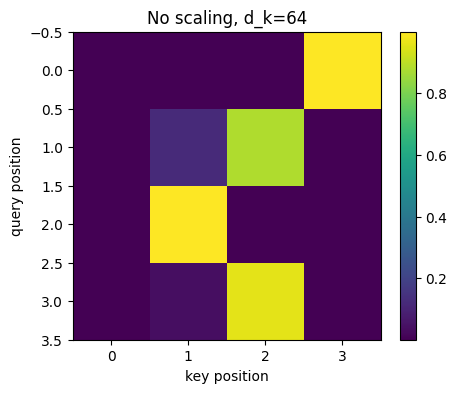

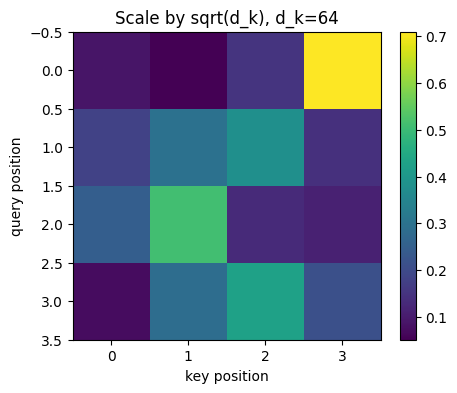

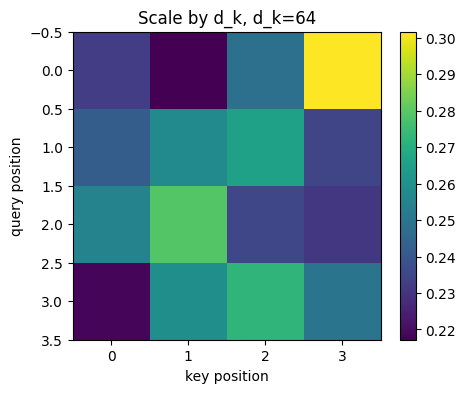

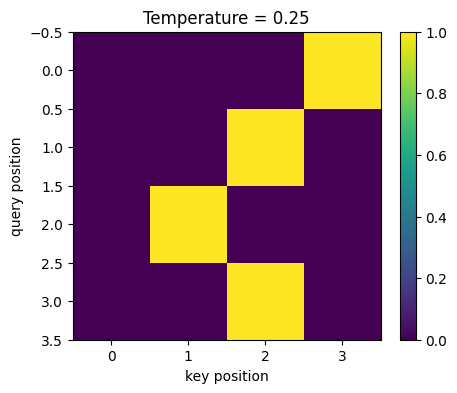

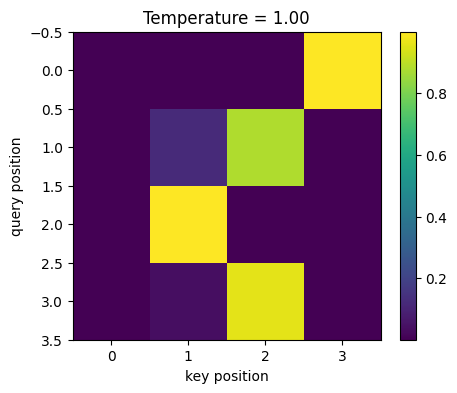

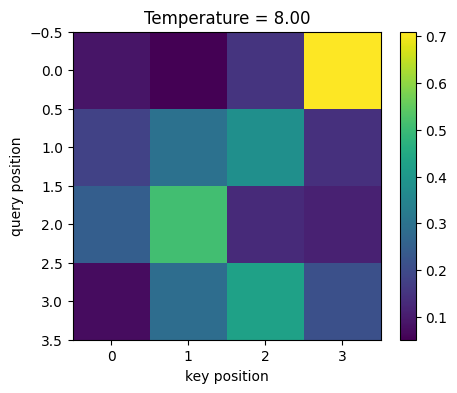

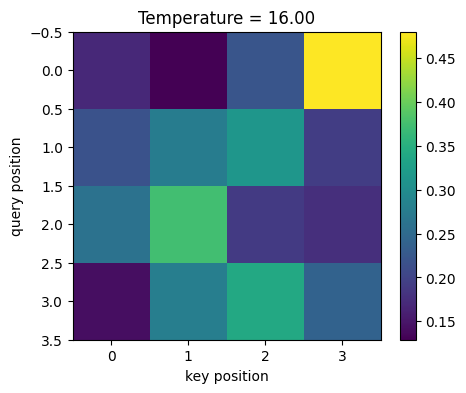

In [6]:
# Exercise 2

def attention_entropy(weights, eps=1e-9):
    return -(weights * torch.log(weights + eps)).sum(dim=-1)

T_demo = 4
d_k_demo = 64

Q_demo = torch.randn(1, T_demo, d_k_demo)
K_demo = torch.randn(1, T_demo, d_k_demo)
demo_scores = Q_demo @ K_demo.transpose(-2, -1)

weights_no_scale = torch.softmax(demo_scores, dim=-1)
weights_sqrt_scale = torch.softmax(demo_scores / math.sqrt(d_k_demo), dim=-1)
weights_dk_scale = torch.softmax(demo_scores / d_k_demo, dim=-1)

max_no_scale = weights_no_scale.max(dim=-1).values.mean()
max_sqrt_scale = weights_sqrt_scale.max(dim=-1).values.mean()
max_dk_scale = weights_dk_scale.max(dim=-1).values.mean()

entropy_no_scale = attention_entropy(weights_no_scale).mean()
entropy_sqrt_scale = attention_entropy(weights_sqrt_scale).mean()
entropy_dk_scale = attention_entropy(weights_dk_scale).mean()

print('Mean max probability')
print('no scale      :', max_no_scale)
print('sqrt(d_k_demo):', max_sqrt_scale)
print('d_k_demo      :', max_dk_scale)

print()
print('Mean entropy')
print('no scale      :', entropy_no_scale)
print('sqrt(d_k_demo):', entropy_sqrt_scale)
print('d_k_demo      :', entropy_dk_scale)

# Temperature experiment on the same demo scores.
temperatures = [0.25, 1.0, math.sqrt(d_k_demo), 16.0]
temperature_weights = {}

for temp in temperatures:
    temperature_weights[temp] = torch.softmax(demo_scores / temp, dim=-1)

# Visualize after filling the variables.
show_attention_heatmap(weights_no_scale, title='No scaling, d_k=64')
show_attention_heatmap(weights_sqrt_scale, title='Scale by sqrt(d_k), d_k=64')
show_attention_heatmap(weights_dk_scale, title='Scale by d_k, d_k=64')
for temp, weights in temperature_weights.items():
    show_attention_heatmap(weights, title=f'Temperature = {temp:.2f}')


### Checks (Exercise 2)


In [7]:
assert Q_demo.shape == (1, 4, 64)
assert K_demo.shape == (1, 4, 64)
assert demo_scores.shape == (1, 4, 4)
assert weights_no_scale.shape == (1, 4, 4)
assert weights_sqrt_scale.shape == (1, 4, 4)
assert weights_dk_scale.shape == (1, 4, 4)
assert check_row_sums(weights_no_scale)
assert check_row_sums(weights_sqrt_scale)
assert check_row_sums(weights_dk_scale)
assert isinstance(temperature_weights, dict)
assert set(temperature_weights.keys()) == {0.25, 1.0, math.sqrt(d_k_demo), 16.0}
for temp, weights in temperature_weights.items():
    assert weights.shape == (1, 4, 4)
    assert check_row_sums(weights)
assert torch.allclose(temperature_weights[1.0], weights_no_scale)
assert torch.allclose(temperature_weights[math.sqrt(d_k_demo)], weights_sqrt_scale)
assert torch.isfinite(attention_entropy(weights_sqrt_scale)).all()
assert max_no_scale >= max_sqrt_scale or torch.isclose(max_no_scale, max_sqrt_scale)
assert entropy_sqrt_scale >= entropy_no_scale or torch.isclose(entropy_sqrt_scale, entropy_no_scale)
print('Exercise 2 passed.')


Exercise 2 passed.


## 3. Find and Fix Attention Bugs

Attention bugs often produce tensors with plausible-looking numbers. Shapes and row-sum checks are your first defense.

### Exercise 3
Each function below contains a common attention mistake. Fix the implementation and keep the function names unchanged.

Useful contracts:
- Correct score shape is `[B, T, T]`, not `[B, d_k, d_k]`.
- Attention probabilities should sum to 1 across keys, so the softmax dimension is the last dimension.
- The output should be `weights @ V`, with shape `[B, T, d_v]`.


In [8]:
# Exercise 3

def fixed_scores(Q, K):
    return Q @ K.transpose(-2, -1)


def fixed_weights(scaled_scores):
    return torch.softmax(scaled_scores, dim=-1)


fixed_scores_result = fixed_scores(Q, K)
fixed_weights_result = fixed_weights(scaled_scores)

print_shape('fixed_scores_result', fixed_scores_result)
print_shape('fixed_weights_result', fixed_weights_result)


fixed_scores_result: shape=(1, 4, 4) dtype=torch.float32
fixed_weights_result: shape=(1, 4, 4) dtype=torch.float32


### Checks (Exercise 3)


In [10]:
assert fixed_scores_result.shape == scores.shape
assert fixed_weights_result.shape == attn_weights.shape
assert torch.allclose(fixed_scores_result, scores)
assert torch.allclose(fixed_weights_result, attn_weights)
assert check_row_sums(fixed_weights_result)
print('Exercise 3 passed.')


Exercise 3 passed.


## 4. Single-Head Self-Attention Module

Now turn the pipeline into a reusable PyTorch layer.

### Exercise 4
Implement `SingleHeadSelfAttention`.

Useful contracts:
- `nn.Linear(in_features, out_features, bias=False)` maps the last dimension from `in_features` to `out_features`.
- `forward(x)` receives `x` with shape `[B, T, d_model]`.
- Return both `out` and `weights`, so we can visualize/debug the attention map.


In [11]:
# Exercise 4

class SingleHeadSelfAttention(nn.Module):
    def __init__(self, d_model, d_k, d_v):
        super().__init__()
        self.q_proj = nn.Linear(d_model, d_k, bias=False)
        self.k_proj = nn.Linear(d_model, d_k, bias=False)
        self.v_proj = nn.Linear(d_model, d_v, bias=False)
        self.d_k = d_k

    def forward(self, x):
        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)
        scores = Q @ K.transpose(-2, -1)
        weights = torch.softmax(scores / math.sqrt(d_k), dim=-1)
        out = weights @ V
        return out, weights

attn_layer = SingleHeadSelfAttention(d_model=6, d_k=4, d_v=4)
out, w = attn_layer(X)

print_shape('out', out)
print_shape('w', w)
print('parameters:', count_parameters(attn_layer))


out: shape=(1, 4, 4) dtype=torch.float32
w: shape=(1, 4, 4) dtype=torch.float32
parameters: 72


### Checks (Exercise 4)


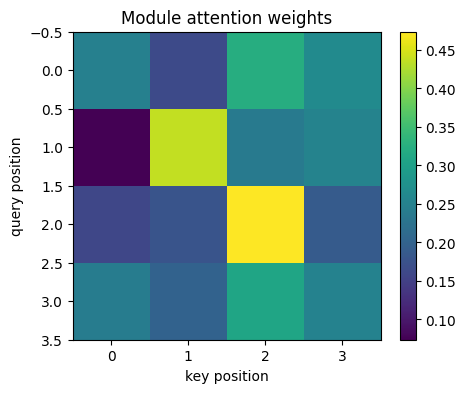

Exercise 4 passed.


In [12]:
assert out.shape == (1, 4, 4)
assert w.shape == (1, 4, 4)
assert check_row_sums(w)
assert count_parameters(attn_layer) == 6 * 4 * 3
show_attention_heatmap(w, title='Module attention weights')
print('Exercise 4 passed.')


## 5. Causal Masking

Autoregressive models must not attend to future tokens. The forbidden region is the upper triangle of the `[T, T]` score matrix.

### Exercise 5
Create a causal mask and implement masked single-head self-attention.

Useful contracts:
- `torch.triu(matrix, diagonal=1)` keeps the part strictly above the main diagonal.
- A boolean mask should use `True` for positions that are forbidden.
- `scores.masked_fill(mask, -1e9)` should happen before softmax.
- If scores have shape `[B, T, T]` and mask has shape `[T, T]`, use `mask.unsqueeze(0)` to broadcast it across the batch.


In [18]:
M = torch.ones(5, 5)
torch.triu(M, diagonal=1)

tensor([[0., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1.],
        [0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0.]])

In [21]:
# Exercise 5

T = X.shape[1]
M = torch.ones(T, T, dtype=bool)
causal_mask = torch.triu(M, diagonal=1)

class MaskedSingleHeadSelfAttention(nn.Module):
    def __init__(self, d_model, d_k, d_v):
        super().__init__()
        self.q_proj = nn.Linear(d_model, d_k, bias=False)
        self.k_proj = nn.Linear(d_model, d_k, bias=False)
        self.v_proj = nn.Linear(d_model, d_v, bias=False)
        self.d_k = d_k

    def forward(self, x, mask=None):
        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask.unsqueeze(0), -1e9)

        weights = torch.softmax(scores, dim=-1)
        out = weights @ V
        return out, weights

masked_attn = MaskedSingleHeadSelfAttention(d_model=6, d_k=4, d_v=4)
masked_out, masked_w = masked_attn(X, mask=causal_mask)
unmasked_out_from_masked_layer, unmasked_w_from_masked_layer = masked_attn(X, mask=None)

print(causal_mask)
print_shape('masked_out', masked_out)
print_shape('masked_w', masked_w)
# show_attention_heatmap(unmasked_w_from_masked_layer, title='Unmasked attention')
# show_attention_heatmap(masked_w, title='Causal attention')


tensor([[False,  True,  True,  True],
        [False, False,  True,  True],
        [False, False, False,  True],
        [False, False, False, False]])
masked_out: shape=(1, 4, 4) dtype=torch.float32
masked_w: shape=(1, 4, 4) dtype=torch.float32


### Checks (Exercise 5)


In [22]:
assert causal_mask.shape == (T, T)
assert causal_mask.dtype == torch.bool
assert causal_mask[0, 1:].all()
assert not causal_mask.diagonal().any()
assert masked_out.shape == (1, 4, 4)
assert masked_w.shape == (1, 4, 4)
assert check_row_sums(masked_w)
assert torch.allclose(masked_w[0][causal_mask], torch.zeros_like(masked_w[0][causal_mask]), atol=1e-5)
assert torch.allclose(unmasked_w_from_masked_layer.sum(dim=-1), torch.ones_like(unmasked_w_from_masked_layer.sum(dim=-1)))
print('Exercise 5 passed.')


Exercise 5 passed.


## 6. Images as Tokens

Vision Transformers use image patches as tokens. We will not build a full ViT here; the goal is only the bridge:

```text
image -> patches -> patch tokens -> patch embeddings -> self-attention
```

### Exercise 6
Take one fake image with shape `[1, 3, 32, 32]`, split it into non-overlapping `8x8` patches, flatten each patch into a token, project tokens into a small embedding dimension, and run self-attention over patches.

Useful contracts:
- `img.unfold(2, patch_size, patch_size)` extracts non-overlapping windows along height.
- `img.unfold(3, patch_size, patch_size)` extracts non-overlapping windows along width.
- After two unfolds, the shape is `[B, C, nH, nW, pH, pW]`.
- `permute` reorders axes; `reshape` is safer than `view` after `permute` because memory may not be contiguous.


In [ ]:
# Exercise 6

img = torch.randn(1, 3, 32, 32)
patch_size = 8

def image_to_patch_tokens(img, patch_size):
    patches = None
    patch_tokens = None
    return patch_tokens

patch_tokens = image_to_patch_tokens(img, patch_size)

patch_dim = None
d_model_patch = 32
patch_proj = None
embedded_patches = None

patch_attn = None
patch_out = None
patch_w = None

print_shape('patch_tokens', patch_tokens)
print_shape('embedded_patches', embedded_patches)
print_shape('patch_out', patch_out)
print_shape('patch_w', patch_w)
# show_attention_heatmap(patch_w, title='Attention over image patches')


### Checks (Exercise 6)


In [ ]:
assert patch_tokens.shape == (1, 16, 3 * 8 * 8)
assert patch_dim == 3 * 8 * 8
assert embedded_patches.shape == (1, 16, 32)
assert patch_out.shape == (1, 16, 16)
assert patch_w.shape == (1, 16, 16)
assert check_row_sums(patch_w)
print('Exercise 6 passed.')


## 7. Optional Discussion: Multi-Head Attention Shapes

If there is time, discuss this without turning it into a coding exercise.

Single-head attention learns one relationship pattern. Multi-head attention repeats attention several times in parallel.

Common shape pattern:
```text
x:       [B, T, D]
q/k/v:   [B, T, h, d_head]
reorder: [B, h, T, d_head]
weights: [B, h, T, T]
concat:  [B, T, h * d_head]
```


## 8. Wrap-up Questions
1. What are `Q`, `K`, and `V`, and why are they three different projections?
2. Why should attention scores have shape `[B, T, T]`?
3. Why do we scale scores by `sqrt(d_k)` before softmax?
4. Why must causal masking happen before softmax?
5. How are image patches similar to text tokens?
